___
<h1> Machine Learning </h1>
<h2> M. Sc. in Electrical and Computer Engineering </h2>
<h3> Instituto Superior de Engenharia / Universidade do Algarve </h3>

[MEEC](https://ise.ualg.pt/en/curso/1477) / [ISE](https://ise.ualg.pt) / [UAlg](https://www.ualg.pt)

Pedro J. S. Cardoso (pcardoso@ualg.pt)
___

# ANN with Sklearn

SKlearn is a simple and efficient tool for data analysis and modeling. It provides a range of supervised and unsupervised learning algorithms through a consistent interface in Python. In particular, it provides a set of tools for neural networks.

We are going to consider the following neural network models:
- **Perceptron**
- **Multi-layer Perceptron (MLP)**

## Perceptron

The **Perceptron is a simple neural network model that learns the weights of the input features to make a binary classification**. The Perceptron is a single-layer neural network with a **step activation function**. In the Sklearn library, the Perceptron model is available in the linear_model module - sklearn.linear_model.Perceptron - and is used for binary classification problems (two classes). It does not allow for activation functions other than the step function.

Although the Perceptron is a simple model, it is the basis for more complex models, such as the Multi-layer Perceptron (MLP). 

So, let us load the necessary libraries and make an example with the Iris dataset.

In [ ]:
from sklearn.datasets import load_iris
from sklearn.linear_model import Perceptron
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

iris = load_iris()

The original iris dataset has three classes. We are going to consider only two classes. So, we are going to consider only the first class (labled = 0) and the other two classes (versicolor and virginica) as a single class. The problem is therefore a binary classification problem, where the target variable is True if the class is 0 and False otherwise.

In [ ]:
X = iris.data
y = iris.target == 0
y

In the next step we are going to split the data into training and test sets and normalize it.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    stratify=iris.target,
                                                    random_state=1)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Now, we are going to train the Perceptron model and predict the target values over the test data.

In [ ]:
perceptron = Perceptron(random_state=1,
                        max_iter=1000,
                        tol=1e-50,
                        verbose=True).fit(X_train_scaled, y_train)

perceptron.score(X_test_scaled, y_test)

Not bad for a simple model! The Perceptron model is a linear model, so it is not able to learn complex patterns. However, it is a good starting point for more complex models, such as the Multi-layer Perceptron (MLP).

 Let us see the weights of the input features.

In [ ]:
perceptron.coef_

Plot the area of the decision boundary

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

X = X_train_scaled[:,[0,1]]
y = y_train

plt.scatter(X[y, 0], X[y, 1], c='blue', label='class 0')
plt.scatter(X[~y, 0], X[~y, 1], c='red', label='other classes')

perceptron = Perceptron().fit(X, y)

x_min, x_max = X_train_scaled[:, 0].min() - 1, X_train_scaled[:, 0].max() + 1
y_min, y_max = X_train_scaled[:, 1].min() - 1, X_train_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))

Z = perceptron.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.4)

## Multi-layer Perceptron (MLP) Classification: Iris dataset
In this section, we'll use the Iris dataset to make out first example.

So, load and split data:

In [ ]:
from sklearn.datasets import load_iris, load_digits
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [ ]:
iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target,
                                                    stratify=iris.target,
                                                    random_state=1)

Prepare a multi-layer perceptron classifier (MLPClassifier), train and get the score over the test data

(https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html)

The default parameters are:
- hidden_layer_sizes=(100,)
- activation='relu'
- solver='adam'
- alpha=0.0001
- ...

In [ ]:
clf = MLPClassifier(verbose=True,  # uncomment to see loss function evolution
                    random_state=1
                    ).fit(X_train, y_train)

score = clf.score(X_test, y_test)
print(f'Final score: {score}')

You probably got a warning message related to the number of iterations. The default number of iterations is 200. The warning message is due to the fact that the optimization algorithm did not converge. 

ok...!? let us see if we can improve this... by increasing the number of iterations

In [ ]:
clf = MLPClassifier(max_iter=1000,
                    random_state=1,
                    verbose=True
                    ).fit(X_train, y_train)

score = clf.score(X_test, y_test)
print(f'Final score: {score}')

That was good! Maybe there were other alternatives, like using more layers...?

In [ ]:
clf = MLPClassifier(hidden_layer_sizes=(100, 100),
                    random_state=1,
                    max_iter=1000,
                    verbose=True
                    ).fit(X_train, y_train)

score = clf.score(X_test, y_test)
print(f'Final score: {score}')

Being a __multi-class classification problem__, the output layer has three neurons (one for each class: setosa, versicolor, and virginica). The __activation function is a softmax function__, which is a generalization of the logistic function to multiple dimensions. 

The sotmax function allows us to interpret the output of the network as probabilities. The class with the highest probability is the predicted class. The probabilities associated to each test instance are: 

In [ ]:
clf.predict_proba(X_test)

Let us see the distribution of the probabilities, for each class, over the test data. This allows us to understand the confidence of the classifier in its predictions.

In [ ]:
plt.hist(clf.predict_proba(X_test))

## Multi-layer Perceptron (MLP) Regression: Bike Sharing dataset

In this section, we'll use the Bike Sharing dataset to make a regression example. This dataset contains the hourly count of rental bikes between years 2017 and 2018 in Seoul, Korea. The goal is to predict the number of bikes rented in a given hour based on the features available.

In [ ]:
df = pd.read_csv('./data/SeoulBikeData.csv')
df.head()

As we can see, the dataset contains both numerical and categorical data. The target variable is the number of rented bikes.

In [ ]:
df.info()

First, we pre-process the data:
- transform the date into a datetime object and extract the hour
- replacing the categorical data by one-hot encoding and normalizing the numerical data.

In [ ]:
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')
df['hour'] = df['Date'].dt.hour
df['month'] = df['Date'].dt.month
df.drop(columns=['Date'], inplace=True)

df = pd.get_dummies(df, columns=['Seasons', 'Holiday', 'Functioning Day'])
df.info()

Now, we split the data into features and target and normalize it.

In [ ]:
X_Seoul = df.drop(columns=['Rented Bike Count'])
y_Seoul = df['Rented Bike Count']

In [ ]:
scaler = StandardScaler()
X_Seoul_scaled = scaler.fit_transform(X_Seoul)

Split the data into training and test sets

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_Seoul_scaled, y_Seoul,
                                                    test_size=0.8,
                                                    random_state=42)

Prepare a multi-layer perceptron regressor (MLPRegressor), train and get the score over the test data

In [ ]:
model = MLPRegressor(max_iter=200,
                     random_state=1,
                     verbose=True
                     ).fit(X_train, y_train)

score = model.score(X_test, y_test)
print(f'Final score (R2): {score}')

You probably got a warning message related to the number of iterations. The default number of iterations is 200. The warning message is due to the fact that the optimization algorithm did not converge. So, let us increase the number of iterations.

In [ ]:
model = MLPRegressor(max_iter=20000,
                     random_state=1,
                     verbose=True
                     ).fit(X_train, y_train)

score = model.score(X_test, y_test)
print(f'Final score (R2): {score}')

It's better... but maybe we can improve this... by increasing the number of hidden layers and neurons.
The previous model has only one hidden layer with 100 neurons. We can try to improve the model by adding more layers and neurons, for example:

In [ ]:
model = MLPRegressor(max_iter=2000,
                     hidden_layer_sizes=(100, 100, 100),
                     random_state=1,
                     verbose=True
                     ).fit(X_train, y_train)

score = model.score(X_test, y_test)
print(f'Final score (R2): {score}')

A slightly better result was obtained. We can try to improve the model by adding more layers and neurons... or we can use a different activation function. The default activation function is the ReLU function. Try it...!

To compare the predicted values with the true values we can plot them.

In [ ]:
y_pred = model.predict(X_test)
plt.plot(y_test, y_pred, 'o')
plt.plot([0,2500], [0,2500], '-', label='test')

# ANN with Keras

Keras is a high-level neural networks API, written in Python and capable of running on top of TensorFlow, CNTK, or Theano. It was developed with a focus on enabling fast experimentation. Being able to go from idea to result with the least possible delay is key to doing good research.

Keras wraps the efficient numerical computation libraries Theano and TensorFlow and allows you to define and train neural network models in just a few lines of code.

In this section, we'll use Keras to build a neural network to classify the digits dataset and to predict the number of bikes rented in a given hour based on the Bike Sharing dataset.

In [3]:
from keras.models import Sequential
from keras.layers import Dense, Input, Dropout
from keras.utils import to_categorical

from tensorflow.keras.utils import plot_model
import tensorflow as tf

from sklearn.metrics import r2_score
from sklearn.datasets import load_digits

import pandas as pd

tf.random.set_seed(42)      # Set random seed for reproducibility

## Classification: Digits dataset

In this section, we'll use Keras to build a neural network to classify the digits dataset. The digits dataset consists of 8x8 pixel images of digits. The goal is to classify the images into one of ten classes (0-9). 

First, we'll load the data, normalize it, and split it into training, validation, and test sets. Then, we'll build a neural network with a simple architecture and train it on the training data. Finally, we'll evaluate the model on the test data.


In [43]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_digits
digits = load_digits()      # We are using the digits dataset, from sklearn.datasets 
X = digits.data
y = digits.target

# Normalize data - values are between 0 and 16
X = X / 16.0


One-hot encode the labels: need because we are using a softmax activation function, which expects one-hot encoded labels - the output layer has 10 neurons (one for each digit). 

Remember that the softmax function outputs a probability distribution over the classes, so the labels must be one-hot encoded. The format of the labels should be a binary matrix, where each row corresponds to a sample, and each column corresponds to a class. The formula is:
- if the label is 0, the one-hot encoded label is [1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
- if the label is 1, the one-hot encoded label is [0, 1, 0, 0, 0, 0, 0, 0, 0, 0]
- ...

The softmax function outputs a probability distribution over the classes, so the labels must be one-hot encoded is computed by:
$$ y = \frac{e^{x_i}}{\sum_{j=1}^{n} e^{x_j}} $$
where $x_i$ is the input to the neuron and $n$ is the number of neurons in the output layer.

In [44]:
y = to_categorical(y)
y[:5]

array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.]])

Split data into training, validation, and test sets

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.3,
                                                    random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test,
                                                test_size=0.5,
                                                random_state=42)

Now, let us build the neural network. We'll use a simple architecture with:
- an input layer with 64 neurons (one for each pixel in the image),
- two hidden layers, each with 100 neurons, and ReLU activation functions,
- an output layer with 10 neurons (one for each digit) and a softmax activation function.
- a dropout layer to avoid overfitting 

In [79]:
tf.random.set_seed(42)                      # Set random seed for reproducibility

m, n = X_train.shape

model = Sequential()                        # Sequential model - a linear stack of layers

model.add(Input(shape=(n,)))                # Input layer with 64 neurons
model.add(Dense(100, activation='relu'))    # Hidden layer with 100 neurons and ReLU activation function
model.add(Dropout(0.1))                     # Dropout layer with 10% of neurons being dropped
model.add(Dense(100, activation='relu'))
model.add(Dense(10, activation='softmax'))  # 10 neurons, one for each digit and softmax activation function

In the next step, we'll compile the model, specifying the optimizer, loss function, and metrics to be used during training. Compiling the model means that Keras will prepare the model for training.

In [80]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',  # Cross-entropy loss function - used for multi-class classification problems
              metrics=['accuracy', 'f1_score']  # Accuracy and F1 score metrics
              )

The shapes of the input and output layers are:

In [81]:
model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_29 (Dense)                │ (None, 100)            │         6,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,610 (68.79 KB)

 Trainable params: 17,610 (68.79 KB)

 Non-trainable params: 0 (0.00 B)

A plot of the architecture is:

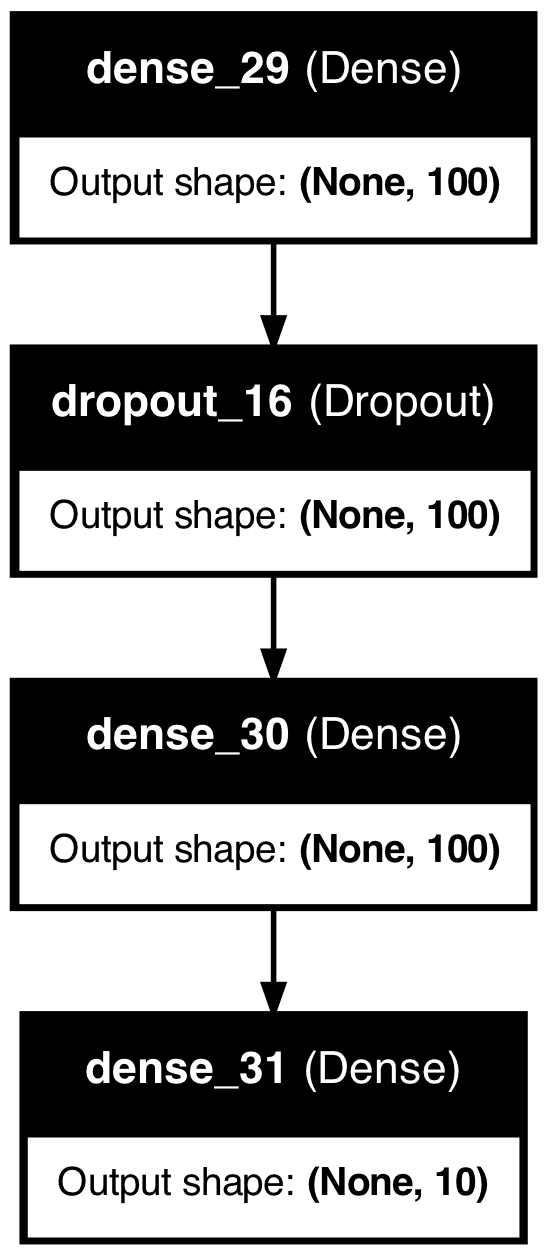

In [82]:
plot_model(model, to_file='model_architecture.png', show_shapes=True, show_layer_names=True)

In [83]:
model.fit(X_train, y_train,
          validation_data=(X_val, y_val),
          epochs=40, 
          batch_size=32,
          )

Epoch 1/40
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3071 - f1_score: 0.2962 - loss: 2.1367 - val_accuracy: 0.7667 - val_f1_score: 0.7450 - val_loss: 1.4114
Epoch 2/40
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7920 - f1_score: 0.7896 - loss: 1.1610 - val_accuracy: 0.9000 - val_f1_score: 0.8921 - val_loss: 0.5732
Epoch 3/40
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8833 - f1_score: 0.8852 - loss: 0.5319 - val_accuracy: 0.9185 - val_f1_score: 0.9095 - val_loss: 0.3431
Epoch 4/40
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9091 - f1_score: 0.9104 - loss: 0.3581 - val_accuracy: 0.9370 - val_f1_score: 0.9312 - val_loss: 0.2640
Epoch 5/40
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9303 - f1_score: 0.9313 - loss: 0.2758 - val_accuracy: 0.9481 - val_f1_score: 0.9452 - val_loss: 0.2163
Epoch 6/40
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9460 - f1_score: 0.9466 - loss: 0.2187 - val_accuracy: 0.9407 - val_f1_score: 0.9364 - val_loss:

Let us see the loss evolution during training and check if there was overfitting.

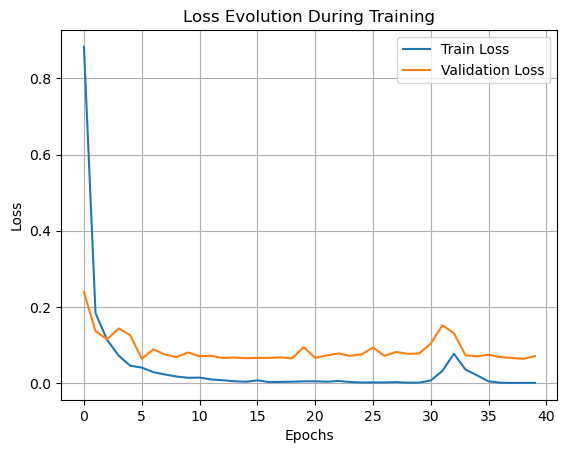

In [88]:
import matplotlib.pyplot as plt
def plot_history(model):
    history = model.history
    
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Loss Evolution During Training')
    plt.legend()
    plt.grid()
    plt.show()
    
plot_history(model)

We achieved an accuracy of 0.9815 on the validation data and a f1-score of 0.9809. Let us evaluate the model on the test data, and see that we get similar results.

In [85]:
res = model.evaluate(X_test, y_test)

print(f'Test loss: {res[0]:.4f}')
print(f'Test accuracy: {res[1]:.4f}')

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 931us/step - accuracy: 0.9854 - f1_score: 0.9852 - loss: 0.0516
Test loss: 0.0634
Test accuracy: 0.9815


Let us do some feature engineering

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.4913 - f1_score: 0.4794 - loss: 1.8266 - val_accuracy: 0.9037 - val_f1_score: 0.9014 - val_loss: 0.5515
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9109 - f1_score: 0.9110 - loss: 0.4357 - val_accuracy: 0.9444 - val_f1_score: 0.9453 - val_loss: 0.2376
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9182 - f1_score: 0.9188 - loss: 0.2343 - val_accuracy: 0.9370 - val_f1_score: 0.9382 - val_loss: 0.2468
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9442 - f1_score: 0.9435 - loss: 0.1687 - val_accuracy: 0.9481 - val_f1_score: 0.9476 - val_loss: 0.2172
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9604 - f1_score: 0.9602 - loss: 0.1200 - val_accuracy: 0.9704 - val_f1_score: 0.9712 - val_loss: 0.1355
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9736 - f1_score: 0.9734 - loss: 0.0980 - val_accuracy: 0.9444 - val_f1_score: 0.9433

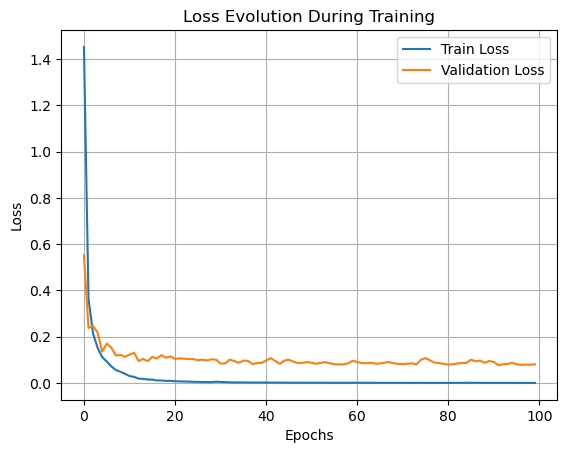

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9819 - f1_score: 0.9762 - loss: 0.0614 
Test loss: 0.0489
Test accuracy: 0.9889


In [126]:
from sklearn.preprocessing import PolynomialFeatures

X = digits.data
y = digits.target

X = X / 16.0

y = to_categorical(y)

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.3,
                                                    random_state=1)

X_val, X_test, y_val, y_test = train_test_split(X_test, y_test,
                                                test_size=0.5,
                                                random_state=1)

m, n = X_train.shape

model = Sequential()
model.add(Input(shape=(n,)))
model.add(Dense(1000, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(1000, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(10, activation='softmax'))

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy', 'f1_score']
              )

model.fit(X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=100, 
            batch_size=128,
            )

plot_history(model)

res = model.evaluate(X_test, y_test)
print(f'Test loss: {res[0]:.4f}')
print(f'Test accuracy: {res[1]:.4f}')

## Regression: Bike Sharing dataset

In this section, we'll use Keras to build a neural network to predict the number of bikes rented in a given hour based on the Bike Sharing dataset.

In [1]:
import pandas as pd
df = pd.read_csv('./data/SeoulBikeData.csv')
df.head()

,Date,Rented Bike Count,Hour,Temperature(C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


First, we prepossess the data:
- transform the date into a datetime object and extract the hour
- replacing the categorical data by one-hot encoding and normalizing the numerical data.

In [2]:
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')
df['hour'] = df['Date'].dt.hour
df['month'] = df['Date'].dt.month
df.drop(columns=['Date'], inplace=True)

df = pd.get_dummies(df, columns=['Seasons', 'Holiday', 'Functioning Day'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Rented Bike Count         8760 non-null   int64  
 1   Hour                      8760 non-null   int64  
 2   Temperature(C)            8760 non-null   float64
 3   Humidity(%)               8760 non-null   int64  
 4   Wind speed (m/s)          8760 non-null   float64
 5   Visibility (10m)          8760 non-null   int64  
 6   Dew point temperature(C)  8760 non-null   float64
 7   Solar Radiation (MJ/m2)   8760 non-null   float64
 8   Rainfall(mm)              8760 non-null   float64
 9   Snowfall (cm)             8760 non-null   float64
 10  hour                      8760 non-null   int32  
 11  month                     8760 non-null   int32  
 12  Seasons_Autumn            8760 non-null   bool   
 13  Seasons_Spring            8760 non-null   bool   
 14  Seasons_

Now, we split the data into features and target and normalize it.

In [3]:
X = df.drop(columns=['Rented Bike Count'])
y = df['Rented Bike Count']

We normalize the data using the StandardScaler from sklearn.

In [4]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

Split the data into training, validation, and test sets

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.3,
                                                    random_state=42)

X_val, X_test, y_val, y_test = train_test_split(X_test, y_test,
                                                test_size=0.5,
                                                random_state=42)

Now, let us build the neural network. We'll use a simple architecture with:
- an input layer with 19 neurons (one for each feature),
- three hidden layers, each with 100 neurons, and ReLU activation functions,
- an output layer with one neuron and a linear activation function.
- a dropout layer to avoid overfitting
- the loss function is the mean squared error
- the metric is the mean absolute error
- the optimizer is the Adam optimization algorithm

In [6]:
from keras.models import Sequential
from keras.layers import Dense, Input, Dropout
import tensorflow as tf

m, n = X_train.shape

tf.random.set_seed(42)                      # Set random seed for reproducibility

model = Sequential()
model.add(Input(shape=(n,)))
model.add(Dense(100, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(100, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(100, activation='relu'))
model.add(Dense(1))

model.compile(
    optimizer='adam',                   # Adam optimization, a stochastic gradient descent method that is based on adaptive estimation of first-order and second-order moments.
    loss='mean_squared_error',          # Mean squared error loss function
    metrics=['mean_absolute_error']     # Mean absolute error metric
)

In [7]:
plot_model(model, to_file='model_architecture.png', show_shapes=True, show_layer_names=True)

NameError: name 'plot_model' is not defined

In [8]:
model.fit(X_train, y_train,
          validation_data=(X_val, y_val),
          epochs=1000, 
          batch_size=32)

Epoch 1/1000
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 692548.5000 - mean_absolute_error: 590.1944 - val_loss: 174737.7188 - val_mean_absolute_error: 289.4204
Epoch 2/1000
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 889us/step - loss: 162295.5625 - mean_absolute_error: 284.0717 - val_loss: 163205.7656 - val_mean_absolute_error: 271.7364
Epoch 3/1000
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 855us/step - loss: 152673.6562 - mean_absolute_error: 271.0913 - val_loss: 158152.5312 - val_mean_absolute_error: 265.5694
Epoch 4/1000
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 891us/step - loss: 147968.3281 - mean_absolute_error: 264.4678 - val_loss: 155021.4844 - val_mean_absolute_error: 261.0343
Epoch 5/1000
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 143565.1875 - mean_absolute_error: 259.2261 - val_loss: 152287.0469 - val_mean_absolute_error: 257.6111
Epoch 6/1000
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 920us/step - loss: 141712.1719 - mean_absolute_error: 257.6405 - val_loss: 149281.2500 - val_mean_absolute_error: 253.3

Let us see the loss evolution during training and check if there was overfitting.

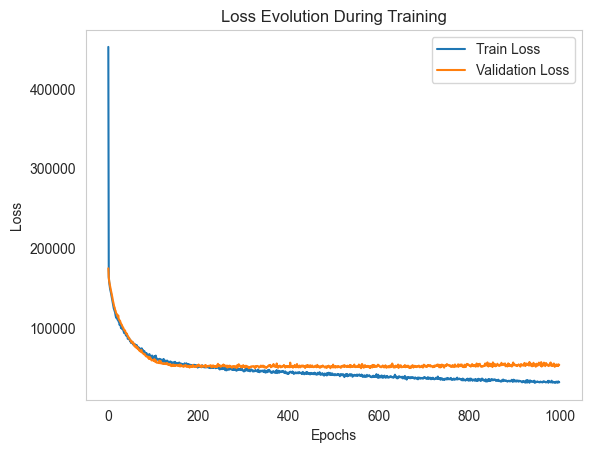

In [9]:
import matplotlib.pyplot as plt
history = model.history

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Evolution During Training')
plt.legend()
plt.grid()
plt.show()

So, we can see that after ~250 epochs the validation stop decreasing (maybe increasing) and the training loss continues to decrease. This is a sign of overfitting. We can stop the training at this point.


In [ ]:
tf.random.set_seed(42)                      # Set random seed for reproducibility

model.fit(X_train, y_train,
          validation_data=(X_val, y_val),
          epochs=250,
          batch_size=32)

Let us evaluate the model on the test data.

In [ ]:
res = model.evaluate(X_test, y_test)
print(f'Test loss: {res[0]:.4f}')
print(f'MSE: {res[1]:.4f}')

If wanted, we can compute the R² score, using the sklearn.metrics.r2_score function.

In [ ]:
from sklearn.metrics import r2_score
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f'R²: {r2:.4f}')

And now, we can plot the predicted values against the true values.

In [ ]:
plt.plot(y_test, y_pred, 'o')
plt.plot([0,2500], [0,2500], '-', label='test')

## Dropout, L1, and L2 Regularization

Dropout, L1, and L2 regularization are techniques used to prevent overfitting in neural networks. We already saw the Dropout technique in the previous examples. Let us see the L1 and L2 regularization techniques. This is just for the sake of curiosity, as the previous examples already showed good results.

In [ ]:
model = Sequential()
model.add(Input(shape=(n,)))
model.add(Dense(100, activation='relu', kernel_regularizer='l1'))  # L1 regularization
model.add(Dropout(0.1))
model.add(Dense(100, activation='relu', kernel_regularizer='l2'))  # L2 regularization
model.add(Dropout(0.1))
model.add(Dense(100, activation='relu', kernel_regularizer='l1l2'))  # L1 and L2 regularization
model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mean_absolute_error']
)

model.fit(X_train, y_train,
          validation_data=(X_val, y_val),
          epochs=400,
          batch_size=32)

res = model.evaluate(X_test, y_test)
print(f'Test loss: {res[0]:.4f}')
print(f'MSE: {res[1]:.4f}')

y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f'R²: {r2:.4f}')

plt.plot(y_test, y_pred, 'o')
plt.plot([0,2500], [0,2500], '-', label='test')
